<a href="https://colab.research.google.com/github/SahilRaut80/Assignments/blob/main/XGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/diabetes.csv')

In [3]:
df.shape

(768, 9)

In [4]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

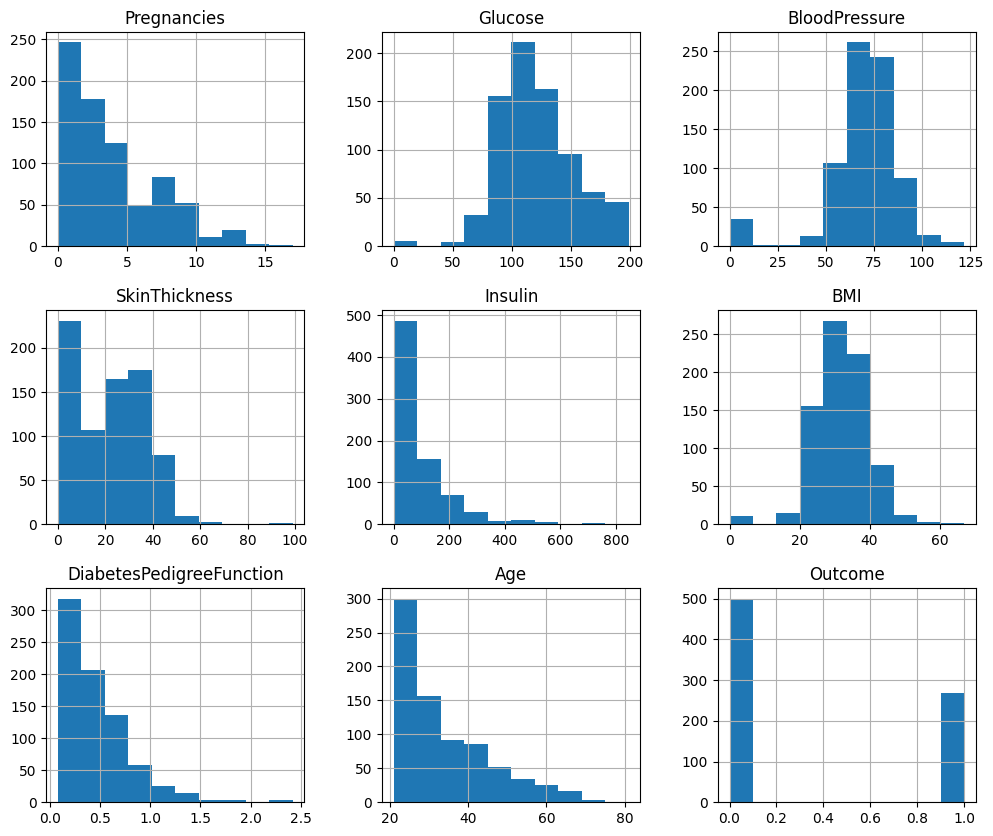

In [7]:
df.hist(figsize=(12,10))

<Axes: >

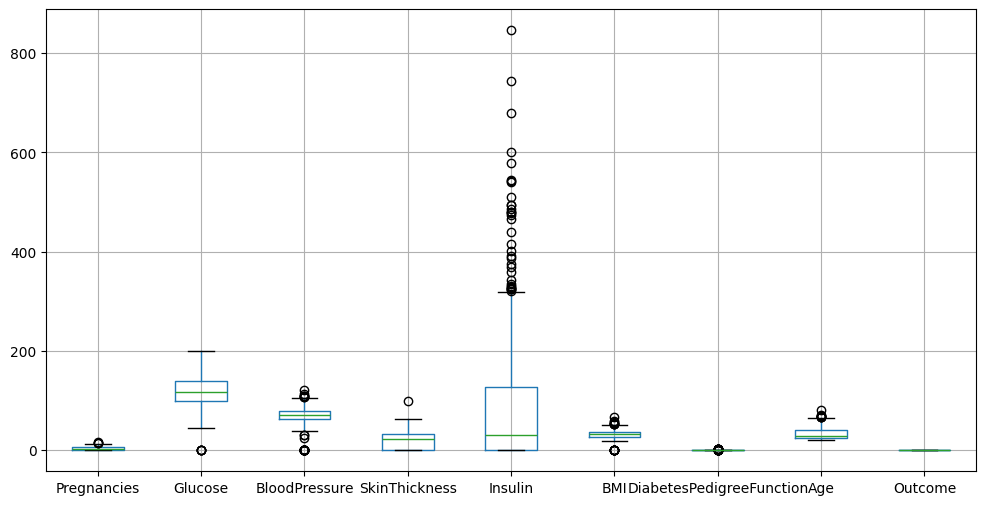

In [8]:
df.boxplot(figsize=(12,6))

In [9]:
for i in df.select_dtypes(include=['int', 'float']).columns:
  q1 = df[i].quantile(0.25)
  q3 = df[i].quantile(0.75)
  iqr = q3 - q1
  lower = q1 - 1.5*iqr
  upper = q3 + 1.5*iqr
  df[i] = df[i].clip(lower,upper)



<Axes: >

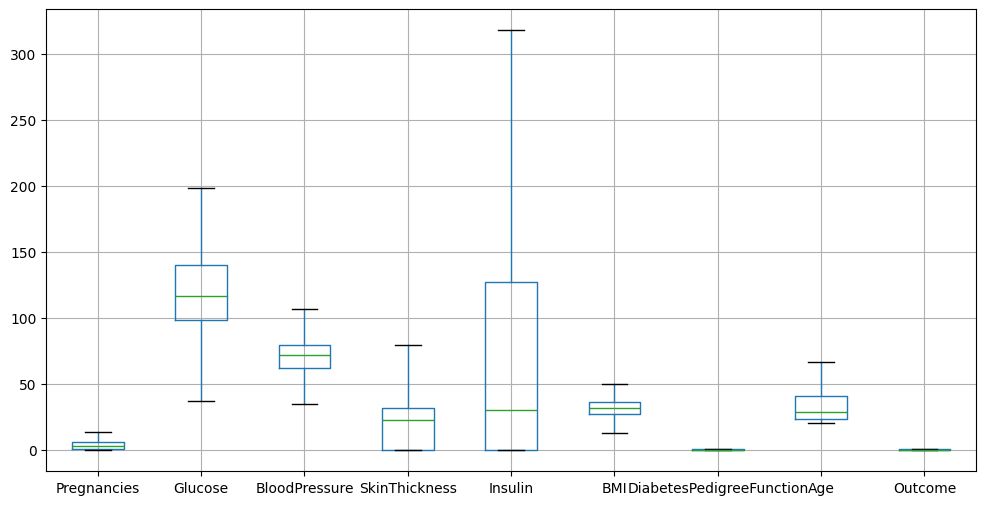

In [10]:
df.boxplot(figsize=(12,6))

In [11]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.837240,121.136230,70.684896,20.511719,73.652669,32.125065,0.458914,33.199870,0.348958
std,3.344157,31.187468,14.197239,15.844744,93.576029,7.049584,0.285596,11.628404,0.476951
min,0.000000,37.125000,35.000000,0.000000,0.000000,13.350000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,13.500000,199.000000,107.000000,80.000000,318.125000,50.550000,1.200000,66.500000,1.000000


In [12]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72,35,0.0,33.6,0.627,50.0,1
1,1.0,85.0,66,29,0.0,26.6,0.351,31.0,0
2,8.0,183.0,64,0,0.0,23.3,0.672,32.0,1
3,1.0,89.0,66,23,94.0,28.1,0.167,21.0,0
4,0.0,137.0,40,35,168.0,43.1,1.200,33.0,1


In [13]:
df['Outcome'].unique()

array([1, 0])

In [14]:
x = df.drop(columns='Outcome')
y = df['Outcome']

In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=32)

In [36]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimetors=50,max_depth = 10)
xgb.fit(x_train,y_train)

xgb_pred = xgb.predict(x_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:53:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimetors" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [38]:
from sklearn.metrics import accuracy_score,classification_report
print(accuracy_score(y_test,xgb_pred))
print(classification_report(y_test,xgb_pred))

0.7857142857142857
              precision    recall  f1-score   support

           0       0.82      0.85      0.84        99
           1       0.71      0.67      0.69        55

    accuracy                           0.79       154
   macro avg       0.77      0.76      0.76       154
weighted avg       0.78      0.79      0.78       154



In [39]:
from lightgbm import LGBMClassifier
lgb = LGBMClassifier()
lgb.fit(x_train,y_train)

lgb_pred = lgb.predict(x_test)

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000051 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 647
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [40]:
from sklearn.metrics import accuracy_score,classification_report
print(accuracy_score(y_test,lgb_pred))

0.7272727272727273


In [30]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
xgbs = XGBClassifier(n_estimetors=50,max_depth = 10)
para_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [31]:
grid = GridSearchCV(
    estimator=xgbs,
    param_grid=para_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [32]:
grid.fit(x_train,y_train)

Fitting 5 folds for each of 972 candidates, totalling 4860 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:46:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimetors" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_estimetors=50, n_jobs=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0], 'gamma': [0, 0.1, 0.3],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7], 'min_child_weight': [1, 3, 5],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1.0]},
             scoring='accuracy', verbose=2)

In [33]:
print('best param ',grid.best_params_)
print('best score ',grid.best_score_)

best param  {'colsample_bytree': 1.0, 'gamma': 0.3, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 1.0}
best score  0.773557243769159


In [41]:
from sklearn.metrics import accuracy_score,precision_score,recall_score

In [44]:
xgb_accu = accuracy_score(y_test,xgb_pred)
xgb_recall = recall_score(y_test,xgb_pred)
xgb_preci = precision_score(y_test,xgb_pred)

In [45]:
lgb_accu = accuracy_score(y_test,lgb_pred)
lgb_recall = recall_score(y_test,lgb_pred)
lgb_preci = precision_score(y_test,lgb_pred)

In [46]:
comparison = pd.DataFrame({
    'Metric' : ['Accuracy','Recall','precision'],
    'XGBoost' : [xgb_accu,xgb_preci,xgb_recall],
    'LGBoost' : [lgb_accu,lgb_preci,lgb_recall]
}
)

In [48]:
comparison

,Metric,XGBoost,LGBoost
0,Accuracy,0.785714,0.727273
1,Recall,0.711538,0.638298
2,precision,0.672727,0.545455


<Axes: >

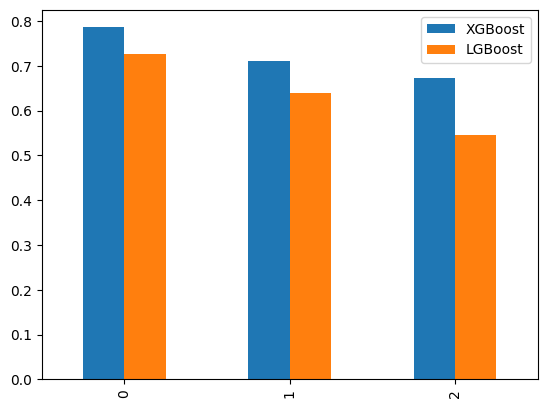

In [50]:
comparison.plot(kind = 'bar')

###Interpretation

LightGBM

Slightly higher accuracy, precision, recall, and F1-score.

Trains faster, especially on large datasets.

Uses less memory.

Best suited for large datasets and faster model training.

XGBoost

Often provides strong performance on small to medium-sized datasets.

Includes powerful regularization, which can reduce overfitting.

May take longer to train than LightGBM.

Generally more stable with default settings.